# 01 — Concurrency sweep (Qwen stream)

Target: `single_model_llm_serving` at `:8000` — `POST /generate_stream`.

Measures *TTFT*, *TPOT* (mean ITL), E2E, throughput, and GPU util while sweeping concurrency.

Start the single-model lab first (`main.ipynb` / uvicorn on port 8000).

## Prediction (fill before running)

> I expect throughput to rise from concurrency 1→4 because the workload manager batches up to `batch_size=4`. Beyond that, TTFT should climb as requests wait; TPOT may rise modestly if the GPU is shared across more active sequences.

Edit this cell with your own hypothesis.

In [1]:
import sys
from pathlib import Path

here = Path.cwd().resolve()
candidates = [
    here,
    here / "observability",
    here.parent / "observability",
    here.parent,  # cwd = experiments/
    here / "notebooks" / "llm-inference" / "observability",
]
for p in [here, *here.parents]:
    candidates.append(p / "notebooks" / "llm-inference" / "observability")
    candidates.append(p / "observability")

obs_root = None
seen: set[Path] = set()
for candidate in candidates:
    candidate = candidate.resolve()
    if candidate in seen:
        continue
    seen.add(candidate)
    if (candidate / "runner.py").is_file():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate.parent))  # local_paths.py
        obs_root = candidate
        break

if obs_root is None:
    raise ModuleNotFoundError(f"observability/runner.py not found; cwd={here}")

from config import load_urls
from runner import concurrency_sweep, save_csv, smoke_stream

urls = load_urls()
BASE = urls["SINGLE_MODEL_URL"]
print("obs_root =", obs_root)
print("BASE =", BASE)

obs_root = /home/mbrdiuser/3D_RP/llm_inference/notebooks/observability
BASE = http://127.0.0.1:8000


In [2]:
# Smoke: one streamed request
smoke = smoke_stream(BASE, "What is the capital of France?")
smoke

{'prompt': 'What is the capital of France?',
 'ok': True,
 'error': None,
 'sequence_id': '4523f484-7c61-4b73-bec3-7dca5483004e',
 'completion_tokens': 21,
 'ttft_s': 0.14141629822552204,
 'tpot_s': 0.04248397797346115,
 'e2e_s': 0.9910958576947451,
 'itl_mean_s': 0.04248397797346115,
 'itl_p50_s': 0.04213840886950493,
 'text': ' 1. In the year 1940, the French government decided to change the capital city'}

In [3]:
PROMPT = "Explain KV cache in one short paragraph."
LEVELS = (1, 2, 4, 8)  # stop early if errors explode

# await — Jupyter already runs an event loop (avoid concurrency_sweep_sync)
rows = await concurrency_sweep(
    BASE,
    PROMPT,
    levels=LEVELS,
    warmup=True,
    sample_gpu=True,
)
rows

[{'concurrency': 1,
  'n_ok': 1,
  'n_err': 0,
  'ttft_p50_s': 0.06109748221933842,
  'ttft_p95_s': 0.06109748221933842,
  'tpot_p50_s': 0.03743219254538417,
  'e2e_p50_s': 0.8097413331270218,
  'throughput_tok_s': 25.934207803006878,
  'throughput_req_s': 1.2349622763336607,
  'wall_s': 0.8097413331270218,
  'gpu_util_mean_pct': 19.0,
  'gpu_util_max_pct': 21.0,
  'mem_used_mean_mib': 13485.0},
 {'concurrency': 2,
  'n_ok': 2,
  'n_err': 0,
  'ttft_p50_s': 0.16323321871459484,
  'ttft_p95_s': 0.16381702832877637,
  'tpot_p50_s': 0.038335474021732804,
  'e2e_p50_s': 0.929942699149251,
  'throughput_tok_s': 45.10293402323077,
  'throughput_req_s': 2.147758763010989,
  'wall_s': 0.9312032777816057,
  'gpu_util_mean_pct': 21.0,
  'gpu_util_max_pct': 21.0,
  'mem_used_mean_mib': 13521.0},
 {'concurrency': 4,
  'n_ok': 4,
  'n_err': 0,
  'ttft_p50_s': 0.17008001171052456,
  'ttft_p95_s': 0.17212058817967774,
  'tpot_p50_s': 0.04841110827401281,
  'e2e_p50_s': 1.1383021771907806,
  'throughp

In [4]:
import pandas as pd

df = pd.DataFrame(rows)
display(df)

path = save_csv(rows, "concurrency_sweep.csv")
print("wrote", path)

,concurrency,n_ok,n_err,ttft_p50_s,ttft_p95_s,tpot_p50_s,e2e_p50_s,throughput_tok_s,throughput_req_s,wall_s,gpu_util_mean_pct,gpu_util_max_pct,mem_used_mean_mib
0,1,1,0,0.061097,0.061097,0.037432,0.809741,25.934208,1.234962,0.809741,19.000000,21.0,13485.0
1,2,2,0,0.163233,0.163817,0.038335,0.929943,45.102934,2.147759,0.931203,21.000000,21.0,13521.0
2,4,4,0,0.170080,0.172121,0.048411,1.138302,73.636006,3.506476,1.140746,20.666667,24.0,14071.0
3,8,8,0,0.784077,1.323949,0.048896,1.761136,72.895057,3.471193,2.304683,19.400000,21.0,14759.0


wrote /home/mbrdiuser/3D_RP/llm_inference/notebooks/observability/results/concurrency_sweep.csv


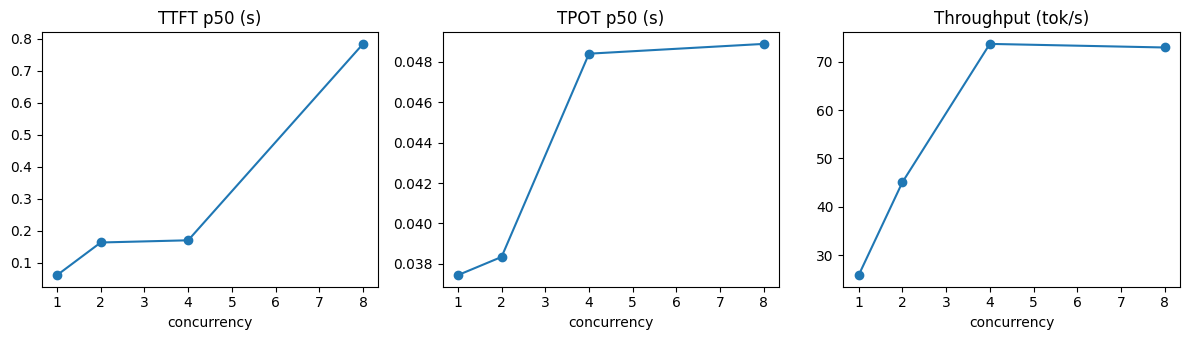

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].plot(df["concurrency"], df["ttft_p50_s"], marker="o")
axes[0].set_title("TTFT p50 (s)")
axes[0].set_xlabel("concurrency")

axes[1].plot(df["concurrency"], df["tpot_p50_s"], marker="o")
axes[1].set_title("TPOT p50 (s)")
axes[1].set_xlabel("concurrency")

axes[2].plot(df["concurrency"], df["throughput_tok_s"], marker="o")
axes[2].set_title("Throughput (tok/s)")
axes[2].set_xlabel("concurrency")

plt.tight_layout()
plt.show()

## Explain

After the sweep, answer:

1. At which concurrency did throughput stop improving?
2. Did TTFT rise faster than TPOT? Why (queue vs decode sharing)?
3. How does this match the workload manager `batch_size=4` / `max_num_seqs=4`?
4. What did GPU util do — compute-bound, waiting on something else, or saturated?

Write notes below.

### Notes

- …